In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

### Cargar datos

In [2]:
df = pd.read_csv("../data/raw/house_prices.csv", na_values="?")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Información General

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Estadísticas Básicas

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Valores Nulos

In [5]:
nulos = df.isnull().sum().sort_values(ascending=False)
nulos = nulos[nulos > 0]
print(nulos)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


### Distribución SalePrice

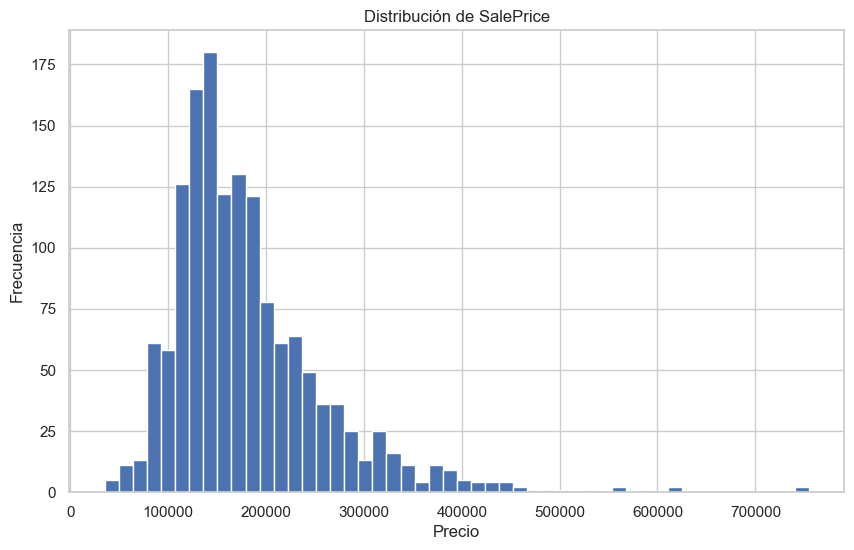

In [6]:
plt.figure(figsize=(10, 6))
df["SalePrice"].hist(bins=50)
plt.title("Distribución de SalePrice")
plt.xlabel("Precio")
plt.ylabel("Frecuencia")
plt.show()

### Correlaciones numéricas

In [7]:
numericas = df.select_dtypes(include=["int64", "float64"])
correlaciones = numericas.corr()["SalePrice"].sort_values(ascending=False)
print(correlaciones)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

### Gráfico correlaciones

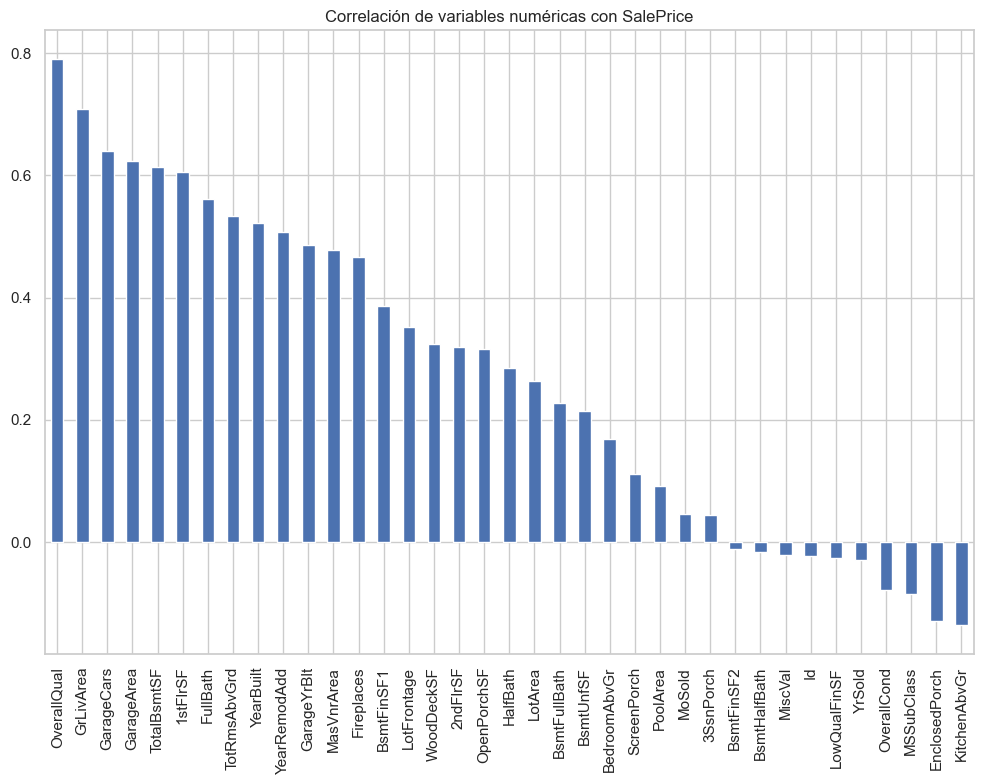

In [8]:
plt.figure(figsize=(10, 8))
correlaciones.drop("SalePrice").plot(kind="bar")
plt.title("Correlación de variables numéricas con SalePrice")
plt.tight_layout()
plt.show()

### Pairplot Top Variables

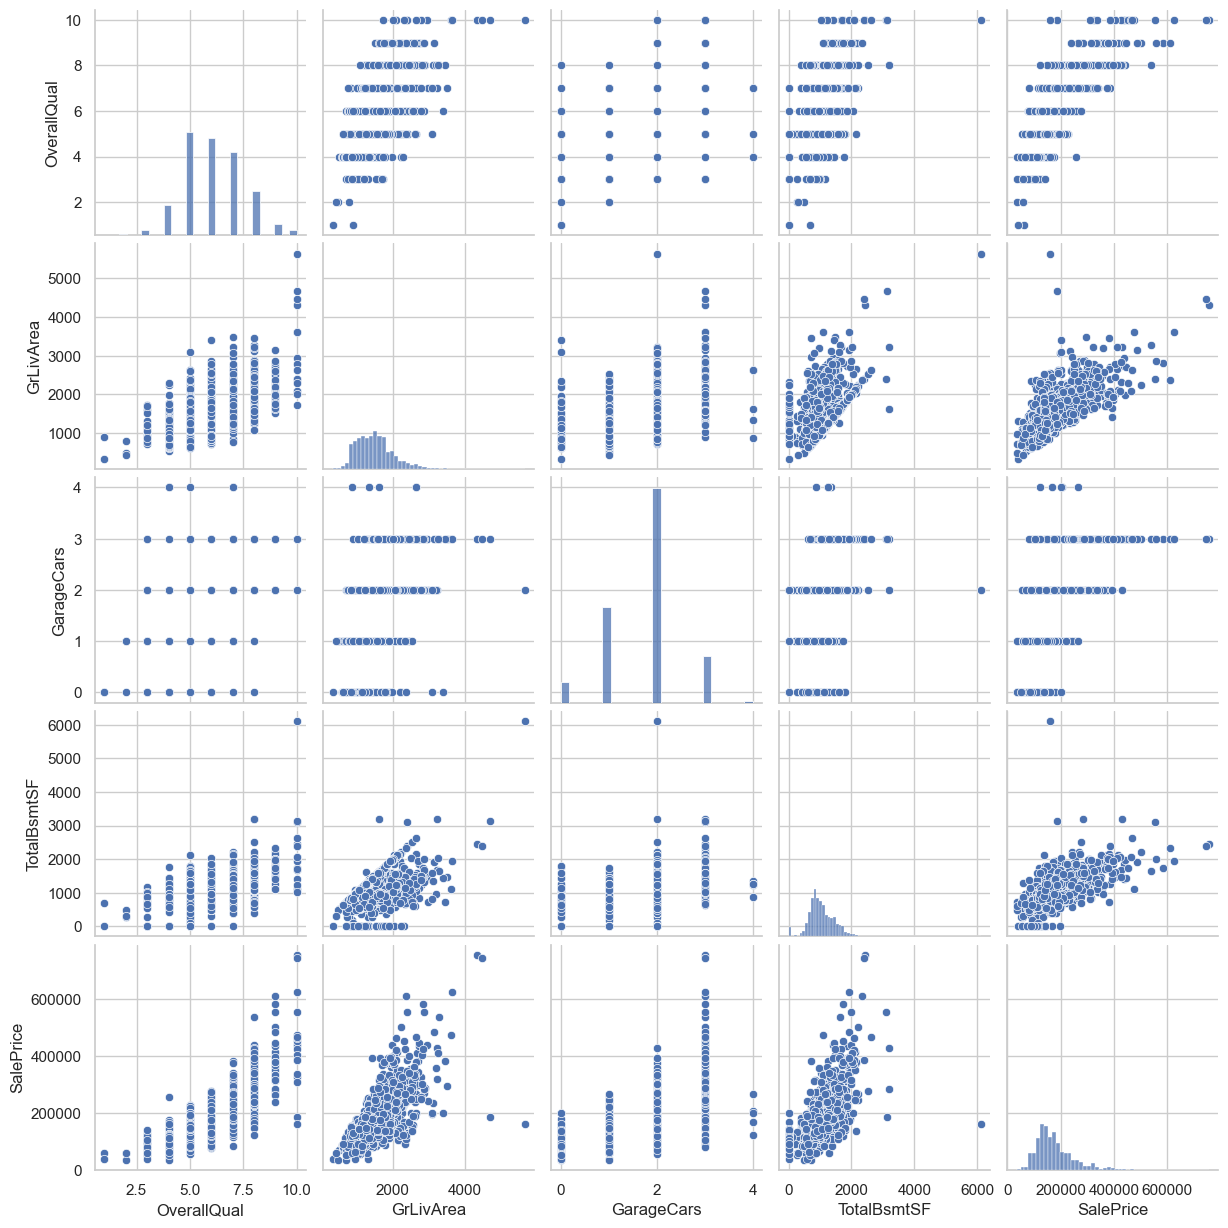

In [9]:
top_vars = ["OverallQual", "GrLivArea", "GarageCars", "TotalBsmtSF", "SalePrice"]
sns.pairplot(df[top_vars])
plt.show()

### Outliers

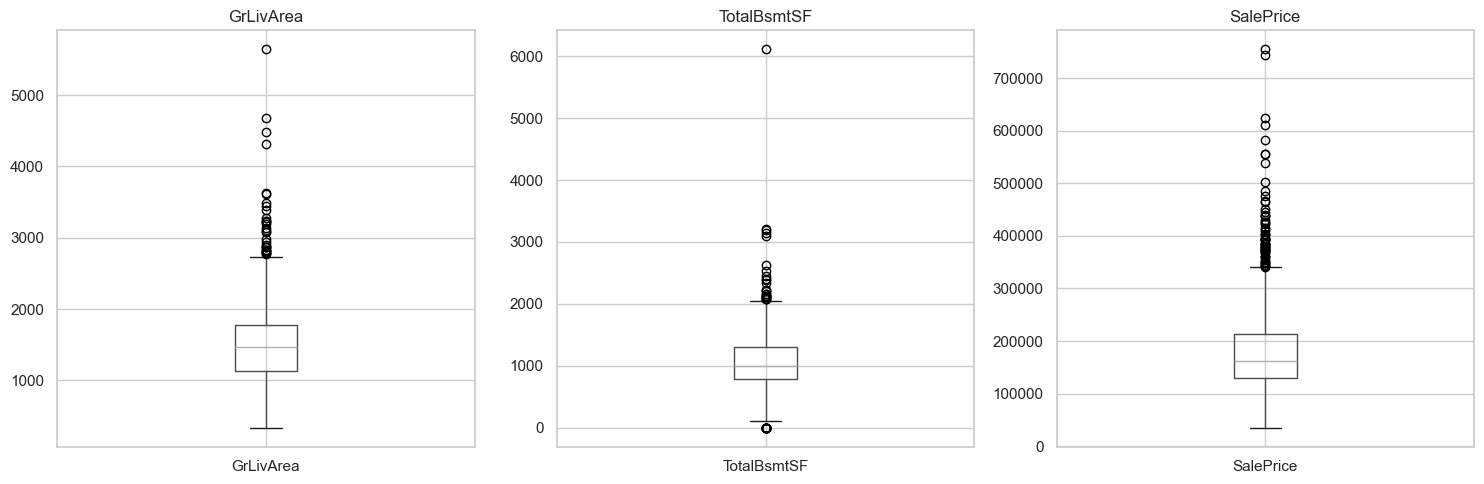

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column="GrLivArea", ax=axes[0])
axes[0].set_title("GrLivArea")

df.boxplot(column="TotalBsmtSF", ax=axes[1])
axes[1].set_title("TotalBsmtSF")

df.boxplot(column="SalePrice", ax=axes[2])
axes[2].set_title("SalePrice")

plt.tight_layout()
plt.show()

### Outliers extremos

In [11]:
print("Casas con GrLivArea > 4000 m²:")
print(df[df["GrLivArea"] > 4000][["GrLivArea", "SalePrice"]])

Casas con GrLivArea > 4000 m²:
      GrLivArea  SalePrice
523        4676     184750
691        4316     755000
1182       4476     745000
1298       5642     160000


###  Eliminar outliers

In [12]:
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]
print(f"Dataset tras eliminar outliers: {df.shape}")

Dataset tras eliminar outliers: (1458, 81)


### Variables categóricas

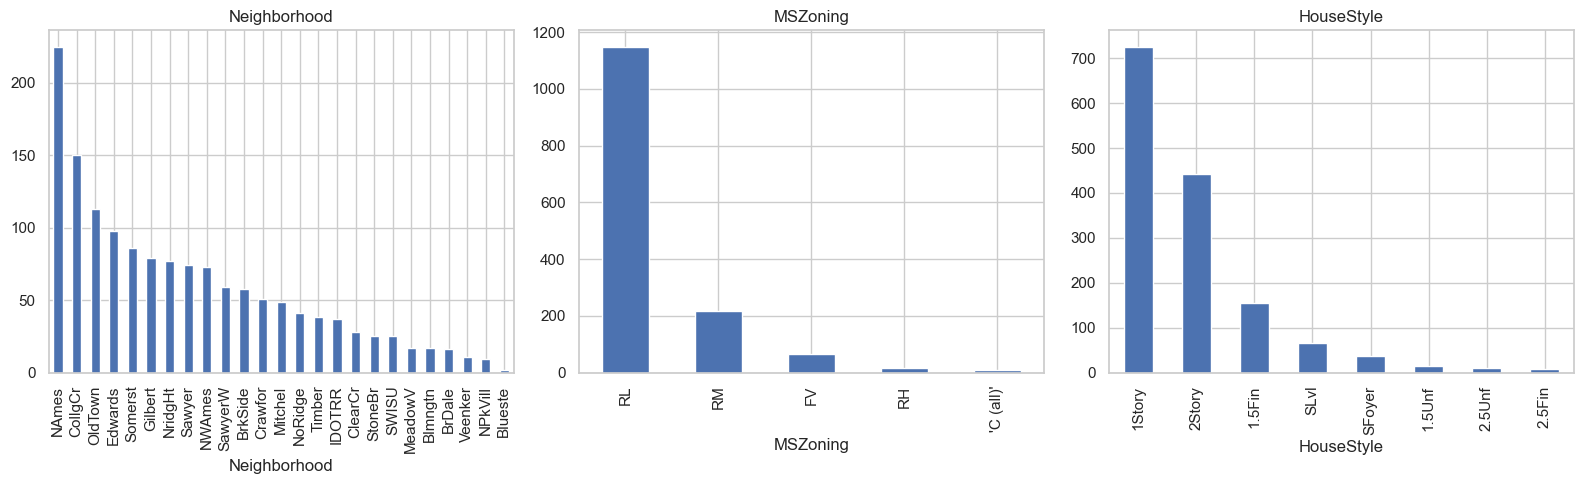

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
df["Neighborhood"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Neighborhood")
df["MSZoning"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("MSZoning")
df["HouseStyle"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("HouseStyle")
plt.tight_layout()
plt.show()

### Precio por barrio

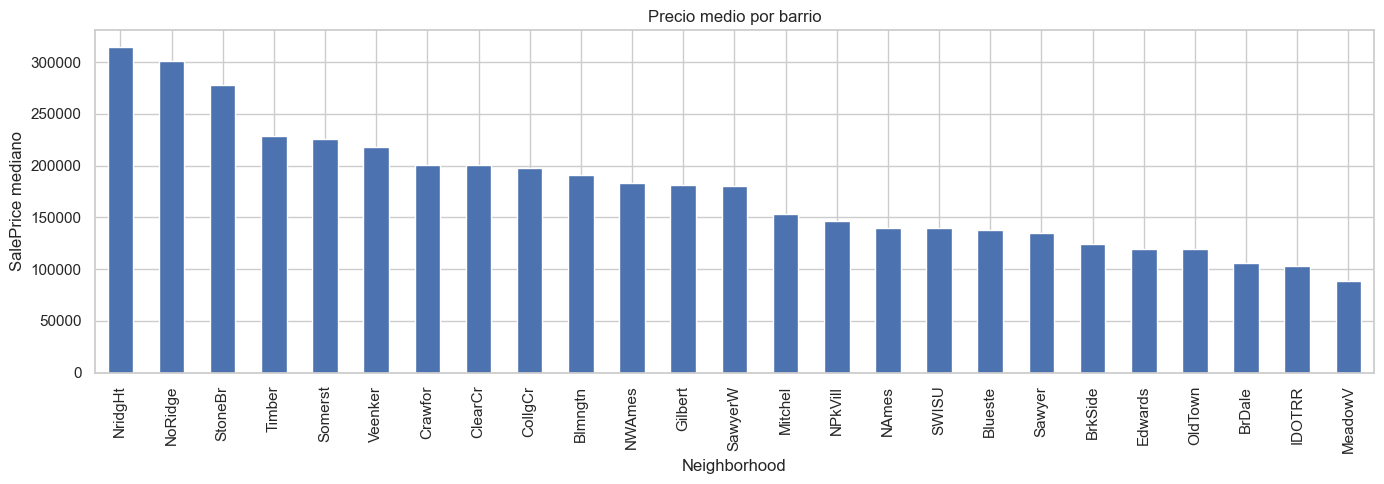

In [14]:
plt.figure(figsize=(14, 5))
df.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False).plot(kind="bar")
plt.title("Precio medio por barrio")
plt.ylabel("SalePrice mediano")
plt.tight_layout()
plt.show()

### Precio por calidad

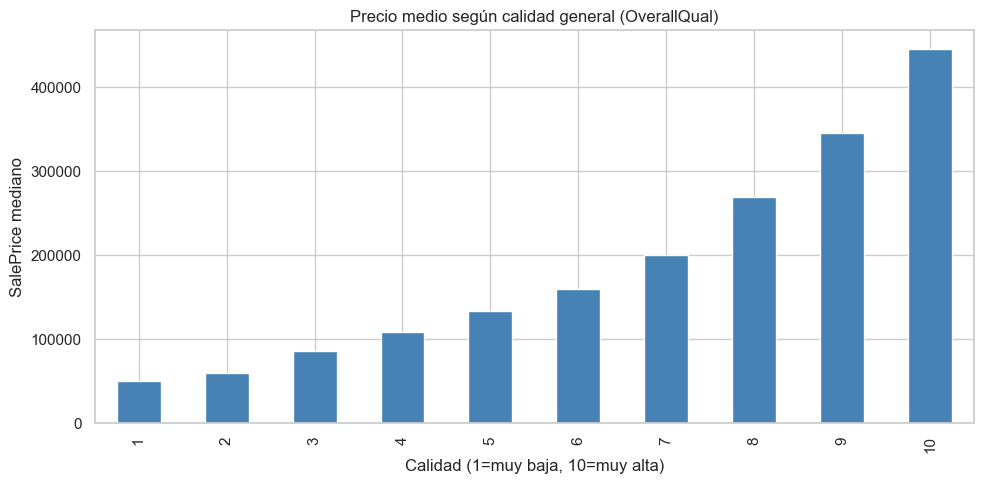

In [15]:
plt.figure(figsize=(10, 5))
df.groupby("OverallQual")["SalePrice"].median().plot(kind="bar", color="steelblue")
plt.title("Precio medio según calidad general (OverallQual)")
plt.xlabel("Calidad (1=muy baja, 10=muy alta)")
plt.ylabel("SalePrice mediano")
plt.tight_layout()
plt.show()

### Precio por año

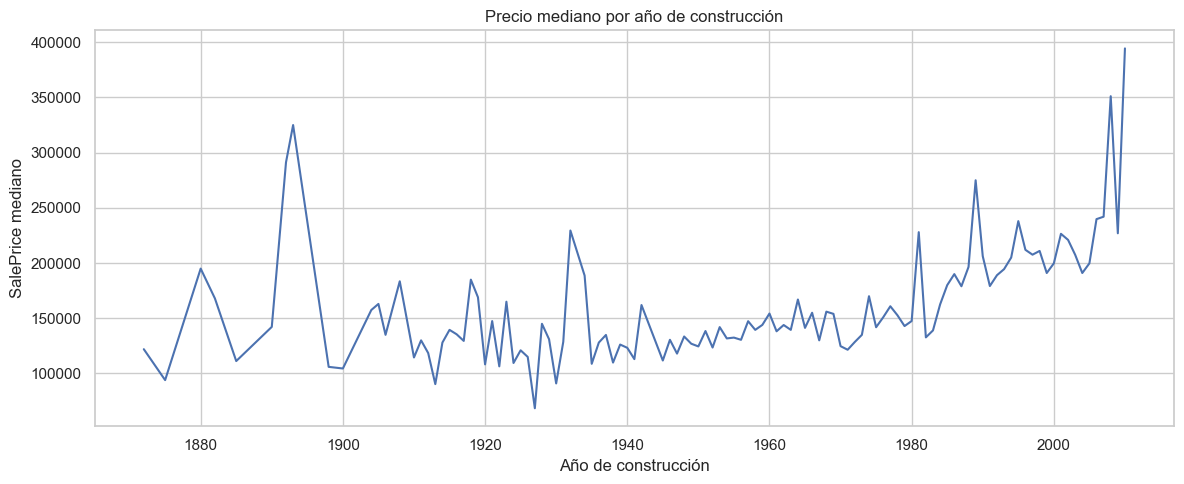

In [16]:
plt.figure(figsize=(12, 5))
df.groupby("YearBuilt")["SalePrice"].median().plot()
plt.title("Precio mediano por año de construcción")
plt.xlabel("Año de construcción")
plt.ylabel("SalePrice mediano")
plt.tight_layout()
plt.show()

### **Conclusions**
DATASET:
- 1460 casas originales, 1458 tras eliminar outliers
- 81 variables (numéricas y categóricas)
- Variable objetivo: SalePrice (distribución sesgada a la derecha)

VARIABLES MÁS IMPORTANTES:
- OverallQual (0.79): a mayor calidad, mayor precio
- GrLivArea (0.71): superficie habitable muy correlacionada con el precio
- GarageCars (0.64) y TotalBsmtSF (0.61): también relevantes
- Neighborhood: gran variación de precios entre barrios
- YearBuilt: tendencia al alza, casas más nuevas valen más

VALORES NULOS:
- PoolQC, MiscFeature, Alley, Fence: muchos nulos = ausencia de característica
- LotFrontage: 259 nulos reales a imputar con la mediana

OUTLIERS:
- 2 casas eliminadas: GrLivArea > 4000 con precio anormalmente bajo
